In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, List
from dotenv import load_dotenv
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph.message import add_messages, BaseMessage

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role":"system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state.get("messages", []))

    print(messages)

    response = llm.invoke(messages)

    return {"messages":[response]}

In [6]:
def summarize(state: ChatState):
    existing_summary = state.get("summary", "")


    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above"

    messages_for_summary = state.get("messages", []) + [HumanMessage(content=prompt)]


    response = llm.invoke(messages_for_summary)

    #keeping only recent 2 messages
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def should_summarize(state:ChatState):

    return len(state["messages"]) > 3

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize)

builder.add_edge(START, "chat")
builder.add_conditional_edges("chat", should_summarize, {True: "summarize", False: END})

builder.add_edge("summarize", END)


In [9]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer)

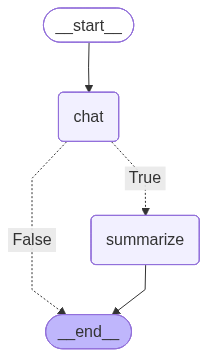

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t4"}}

In [12]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n-----STATE------")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, m.content[:80])

In [13]:
out = graph.invoke(
    {"messages": [HumanMessage(content="Quantum Computing")], "summary":''},
    config=config
)

[HumanMessage(content='Quantum Computing', additional_kwargs={}, response_metadata={}, id='94baeb07-fecd-4f0c-ac94-3a1429652b88')]


In [14]:
print(out["messages"][-1].content)

## Quantum Computing – A Primer

### 1. What makes a quantum computer different?
| Classical Computer | Quantum Computer |
|--------------------|-------------------|
| **Bit** – a binary digit that is either **0** or **1**. | **Qubit** – can be in a superposition of **0** **and** **1** simultaneously. |
| Operations are deterministic Boolean logic (AND, OR, NOT). | Operations are **unitary transformations** (quantum gates) that manipulate amplitudes and phases. |
| Information is stored in the state of transistors, magnetic domains, etc. | Information is stored in quantum states of photons, ions, superconducting circuits, etc. |
| Errors are usually bit‑flips or stuck‑at faults; error‑correction is relatively simple. | Errors are **decoherence** and **gate infidelity**; need sophisticated quantum error‑correction (surface codes, etc.). |
| Scaling is limited mainly by power, heat, and fabrication. | Scaling is limited by maintaining coherence, connectivity, and error rates. |

### 2. C

In [15]:
show_state()


-----STATE------
summary: 
num_messages: 2
messages:
- HumanMessage Quantum Computing
- AIMessage ## Quantum Computing – A Primer

### 1. What makes a quantum computer different?


In [16]:
out = graph.invoke(
    {"messages": [HumanMessage(content="How is ALber Einstein related to quantum physics?")],},
    config=config
)

[HumanMessage(content='Quantum Computing', additional_kwargs={}, response_metadata={}, id='94baeb07-fecd-4f0c-ac94-3a1429652b88'), AIMessage(content='## Quantum Computing – A Primer\n\n### 1. What makes a quantum computer different?\n| Classical Computer | Quantum Computer |\n|--------------------|-------------------|\n| **Bit** – a binary digit that is either **0** or **1**. | **Qubit** – can be in a superposition of **0** **and** **1** simultaneously. |\n| Operations are deterministic Boolean logic (AND, OR, NOT). | Operations are **unitary transformations** (quantum gates) that manipulate amplitudes and phases. |\n| Information is stored in the state of transistors, magnetic domains, etc. | Information is stored in quantum states of photons, ions, superconducting circuits, etc. |\n| Errors are usually bit‑flips or stuck‑at faults; error‑correction is relatively simple. | Errors are **decoherence** and **gate infidelity**; need sophisticated quantum error‑correction (surface codes, e

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01kf64b6s6es7rsbg1wq3dbfv1` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8086, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [17]:
print(out["messages"][-1].content)

show_state()

## Albert Einstein and Quantum Physics – A Short‑but‑Rich Story  

Albert Einstein is often remembered as the father of **relativity**, but his name appears over and over again in the early development of **quantum theory**—both as a pioneering contributor and as one of its most famous critics. Below is a concise, chronological map of the ways Einstein shaped, challenged, and helped refine quantum physics.

---

### 1. The Birth of Quantum Ideas (1900‑1905)

| Year | Einstein’s Contribution | Why It Matters for Quantum Theory |
|------|------------------------|-----------------------------------|
| **1900** | **Statistical mechanics of black‑body radiation** (building on Planck’s 1900 work). | Showed that the classical equipartition theorem fails at high frequencies, hinting that energy must be quantized. |
| **1905** (the “*Annus Mirabilis*”) | **Photo‑electric effect paper** – *“On a Heuristic Viewpoint Concerning the Generation and Transformation of Light.”* | Proposed that light co

In [ ]:
out = graph.invoke(
    {"messages": [HumanMessage(content="Some of Einstein famous work")]},
    config=config
)

[HumanMessage(content='Quantum Computing', additional_kwargs={}, response_metadata={}, id='5e97a01d-1e39-4e1d-9a68-a097629f0bba'), AIMessage(content='## Quantum Computing – A Friendly, Yet Thorough Introduction\n\nWelcome! 🎉 If you’ve heard the buzzword “quantum computing” and are curious about what it actually means, you’re in the right place. Below is a self‑contained primer that walks you through the core ideas, the technology that makes it possible, the most famous algorithms, the challenges we still face, and where the field might be heading. Feel free to let me know if you’d like to dive deeper into any particular topic (e.g., hardware platforms, error correction, specific algorithms, or practical applications).\n\n---\n\n## 1. Why Quantum Computing? (The “Why”)\n\nClassical computers store and manipulate **bits** that are either 0 or 1. They excel at a huge variety of tasks, but certain problems (e.g., factoring large numbers, simulating quantum chemistry, optimizing massive com

In [21]:
print(out["messages"][-1].content)

show_state()

Below is a **concise but comprehensive guide** to the works that made Albert Einstein a household name in physics.  
I’ve grouped them by theme, given the original publication year (and where possible the journal), a one‑sentence description of the main result, and why it matters today.

---

## 1. Relativity – The Geometry of Space‑Time  

| Year | Paper / Lecture | Core Idea | Why It’s Famous |
|------|----------------|----------|-----------------|
| **1905** | **“On the Electrodynamics of Moving Bodies”** (Annalen der Physik) | **Special Relativity** – the laws of physics (including the speed of light) are the same in all inertial frames; introduces Lorentz transformations, time dilation, length contraction, and the equivalence of mass & energy **E = mc²**. | Revolutionized our notion of space and time; the mass‑energy relation underlies nuclear power and particle physics. |
| **1907** | **“On the Relativity Principle and the Conclusions Drawn from It”** (lecture) | First explicit s

In [22]:
out = graph.invoke(
    {"messages": [HumanMessage(content="Explain theory of relativity")]},
    config=config
)

[HumanMessage(content='Quantum Computing', additional_kwargs={}, response_metadata={}, id='7d7f5c3e-2c0d-4cb4-a9e5-290c5345addd'), AIMessage(content='## Quantum Computing – A Primer\n\nBelow is a self‑contained overview that takes you from the very basics (what a qubit is) to the frontiers of research and industry. Feel free to let me know which parts you’d like to dive deeper into!\n\n---\n\n### 1. Why Quantum Computing?\n| Classical Computer | Quantum Computer |\n|--------------------|-------------------|\n| Bits are **0 or 1** | **Qubits** can be **0,\u202f1, or any superposition** of both |\n| Parallelism comes from **multiple cores, threads, SIMD** | Parallelism is intrinsic: a register of *n* qubits can represent **2ⁿ** amplitudes simultaneously |\n| Algorithms are limited by **deterministic** logic | Quantum algorithms exploit **interference** and **entanglement** to solve some problems exponentially faster (e.g., factoring, unstructured search) |\n\n---\n\n### 2. Core Physical 

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01kf64b6s6es7rsbg1wq3dbfv1` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 12399, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
print(out["messages"][-1].content)

show_state()